[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/linear_algebra/06_eigenvalues_eigenvectors_spectral_theory/first_principles.ipynb)

# Module 06 — Eigenvalues, Eigenvectors, and Spectral Theory

## 1. Why This Module Exists

A matrix is a rule for moving vectors. Applied twice, ten times, or a million times, that rule
becomes hard to read off the entries: $A^{10}$ tells you almost nothing by inspection.

Eigenvectors are the directions in which the rule collapses to a single number. Along an
eigenvector, $A$ is multiplication by a scalar, and a million applications is that scalar raised
to the millionth power.

The whole subject asks one question: **when is there a basis in which $A$ acts diagonally?**
Not every matrix has one. The central theorem of this module says that every real symmetric
matrix does, and that the basis can be taken orthonormal.

That single fact is what makes principal component analysis, graph clustering, covariance
whitening, second-order optimization and quantum measurement all the same computation.

## 2. Intuition

Picture the unit circle in $\mathbb{R}^2$ and a symmetric matrix $A$. The image $\{Ax : \lVert x \rVert = 1\}$
is an ellipse.

The ellipse has two perpendicular axes. Those axes are the eigenvectors, and the semi-axis
lengths are the absolute eigenvalues.

A generic vector rotates when you apply $A$: its image points somewhere else. A vector along an
axis does not rotate; it only stretches.

Symmetry is exactly the hypothesis that makes the two invariant directions perpendicular and
aligned with the ellipse axes. Drop it and the unit circle still maps to an ellipse, but the
eigenvector directions come away from the axes and tilt towards each other — and if they merge,
the matrix has no eigenbasis at all.

Everything below is bookkeeping for that picture in $n$ dimensions.

The first code cell is the notebook preamble. It fixes plotting defaults, seeds the single
random generator used everywhere in this notebook, and prints the machine epsilon that later
residual claims are measured against.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

EPS = np.finfo(float).eps
print(f"machine epsilon = {EPS:.4e}")

machine epsilon = 2.2204e-16


Every reconstruction residual reported later is quoted as a multiple of this number.

The next cell draws the picture described above for

$$
A = \begin{pmatrix} 2 & 1 \\ 1 & 2 \end{pmatrix},
$$

whose eigenvalues are $3$ and $1$ with eigenvectors along $(1,1)$ and $(1,-1)$. It maps the unit
circle through $A$, overlays the two eigenvector axes scaled by their eigenvalues, and adds one
non-eigenvector together with its image.

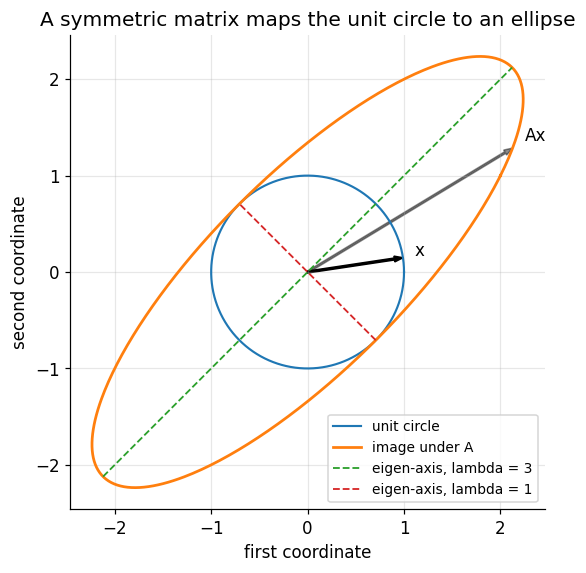

eigenvalues (descending): [3. 1.]
angle between eigenvectors (degrees): 90.0


In [2]:
A2 = np.array([[2.0, 1.0], [1.0, 2.0]])
lam2, Q2 = np.linalg.eigh(A2)
order = np.argsort(lam2)[::-1]
lam2, Q2 = lam2[order], Q2[:, order]

t = np.linspace(0.0, 2.0 * np.pi, 400)
circle = np.vstack([np.cos(t), np.sin(t)])
ellipse = A2 @ circle

x = np.array([1.0, 0.15])
x = x / np.linalg.norm(x)
Ax = A2 @ x

fig, ax = plt.subplots(figsize=(5.6, 5.6))
ax.plot(circle[0], circle[1], lw=1.4, label="unit circle")
ax.plot(ellipse[0], ellipse[1], lw=1.8, label="image under A")
for j in range(2):
    v = Q2[:, j] * lam2[j]
    ax.plot([-v[0], v[0]], [-v[1], v[1]], lw=1.2, ls="--",
            label=f"eigen-axis, lambda = {lam2[j]:.0f}")
ax.arrow(0, 0, x[0], x[1], width=0.02, length_includes_head=True, color="k")
ax.arrow(0, 0, Ax[0], Ax[1], width=0.02, length_includes_head=True, color="k", alpha=0.45)
ax.annotate("x", x * 1.12)
ax.annotate("Ax", Ax * 1.06)
ax.set_aspect("equal")
ax.set_xlabel("first coordinate")
ax.set_ylabel("second coordinate")
ax.set_title("A symmetric matrix maps the unit circle to an ellipse")
ax.legend(loc="lower right", fontsize=9)
plt.show()

print("eigenvalues (descending):", lam2)
print("angle between eigenvectors (degrees):",
      np.degrees(np.arccos(abs(Q2[:, 0] @ Q2[:, 1]))))

The two dashed axes are perpendicular to machine precision — the printed angle is $90$ degrees —
and their half-lengths are exactly the eigenvalues $3$ and $1$.

The black arrows show a non-eigenvector: $x$ and $Ax$ point in different directions. Only the
dashed directions are fixed.

## 3. Definitions

Throughout, $A \in \mathbb{C}^{n \times n}$, $A^{\ast}$ is the conjugate transpose, and
$A^{\top}$ is the plain transpose. Vectors are columns. The convention for this repository is
recorded in [the notation register](../../docs/notation.md); the two rulings that matter here
are that **eigenvalues are listed in descending order** and that norms are written
$\lVert x \rVert$.

### Definition 3.1 — Eigenpair

A scalar $\lambda \in \mathbb{C}$ and a vector $x \in \mathbb{C}^n$ with $x \neq 0$ form an
**eigenpair** of $A$ when

$$
Ax = \lambda x .
$$

The requirement $x \neq 0$ is not decoration: $A0 = \lambda 0$ holds for every scalar, so the
zero vector would make the definition vacuous.

### Definition 3.2 — Characteristic polynomial

The **characteristic polynomial** of $A$ is

$$
p_A(z) = \det(A - zI) .
$$

It is a degree-$n$ polynomial in $z$ with leading coefficient $(-1)^n$, and $\lambda$ is an
eigenvalue of $A$ exactly when $p_A(\lambda) = 0$, because $A - \lambda I$ is singular precisely
when its null space is non-trivial.

### Definition 3.3 — Eigenspace and the two multiplicities

For an eigenvalue $\lambda$ of $A$:

- the **eigenspace** is $E_\lambda = \operatorname{Null}(A - \lambda I)$;
- the **geometric multiplicity** is $g_\lambda = \dim E_\lambda$;
- the **algebraic multiplicity** $m_\lambda$ is the multiplicity of $\lambda$ as a root of $p_A$.

The inequality $1 \le g_\lambda \le m_\lambda \le n$ always holds. The left inequality is the
existence of one eigenvector; the middle one is proved as Proof 5.9.

### Definition 3.4 — Diagonalizable and defective

$A$ is **diagonalizable** when $A = PDP^{-1}$ for some invertible $P$ and diagonal $D$,
equivalently when $\mathbb{C}^n$ has a basis of eigenvectors of $A$.

$A$ is **defective** when it is not diagonalizable, equivalently when $g_\lambda \lt m_\lambda$
for at least one eigenvalue.

### Definition 3.5 — Symmetric, Hermitian, normal, unitary

- $A \in \mathbb{R}^{n \times n}$ is **symmetric** when $A^{\top} = A$.
- $A \in \mathbb{C}^{n \times n}$ is **Hermitian** when $A^{\ast} = A$.
- $A$ is **normal** when $A^{\ast}A = AA^{\ast}$.
- $U$ is **unitary** when $U^{\ast}U = I$; a real unitary matrix is called **orthogonal** and
  written $Q$, so $Q^{\top}Q = I$.

Every Hermitian matrix is normal; so is every unitary and every skew-Hermitian matrix.

### Definition 3.6 — Rayleigh quotient

For real symmetric $A$ and $x \neq 0$,

$$
R_A(x) = \frac{x^{\top} A x}{x^{\top} x} .
$$

It is the value $\lambda$ would have to take if $x$ were an eigenvector, in the least-squares
sense, and it is invariant under rescaling $x$.

### Definition 3.7 — Spectrum, spectral radius, angle

The **spectrum** $\operatorname{spec}(A)$ is the set of eigenvalues. The **spectral radius** is

$$
\rho(A) = \max_{\lambda \in \operatorname{spec}(A)} \lvert \lambda \rvert .
$$

For unit vectors $u, v$ the **angle** between the lines they span is
$\theta(u,v) = \arccos \lvert u^{\ast} v \rvert \in [0, \pi/2]$, so that
$\sin \theta(u,v) = 0$ exactly when $u$ and $v$ are parallel.

## 4. Main Results

Theorem 4.1 is the general structural fact and Theorem 4.2 — the result the module is named
after — is deduced from it. Theorem 4.3 identifies exactly which complex matrices behave the same
way.

Theorems 4.4 to 4.8 are the tools that make the spectral theorem usable in floating-point
arithmetic: a variational formula, two perturbation bounds, a convergence rate and a localization
result. Theorem 4.9 collects the two bounds quoted rather than proved, and Proposition 4.10 records
the multiplicity bookkeeping used throughout.

### Theorem 4.1 — Schur triangularization

Let $A \in \mathbb{C}^{n \times n}$. There exist a unitary $U \in \mathbb{C}^{n \times n}$ and an
upper triangular $T \in \mathbb{C}^{n \times n}$ with

$$
A = UTU^{\ast} .
$$

The diagonal entries of $T$ are the eigenvalues of $A$, each repeated according to its algebraic
multiplicity.

**Hypotheses.** Only that the field is $\mathbb{C}$. That is needed so the characteristic
polynomial has a root at every stage of the induction; over $\mathbb{R}$ the statement is false,
as the rotation matrix of Example 6.5 shows.

Proved as Proof 5.1.

### Theorem 4.2 — Spectral theorem for real symmetric matrices

Let $A \in \mathbb{R}^{n \times n}$ with $A^{\top} = A$. Then there exist a real orthogonal
$Q$ and a real diagonal $\Lambda = \operatorname{diag}(\lambda_1, \dots, \lambda_n)$ with
$\lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_n$ such that

$$
A = Q \Lambda Q^{\top}, \qquad Q^{\top} Q = I .
$$

Equivalently $A = \sum_{i=1}^{n} \lambda_i q_i q_i^{\top}$, where $q_i$ is the $i$-th column
of $Q$.

**Consequences, not assumptions.** Every eigenvalue is real; eigenvectors for distinct
eigenvalues are orthogonal; and $g_\lambda = m_\lambda$ for every eigenvalue, so a symmetric
matrix is never defective.

**Hypotheses.** Symmetry is doing all the work. Without it the eigenvalues need not be real
and the eigenvectors need not be orthogonal or even span the space; Example 6.5 and the code in
Section 7 exhibit both failures.

Proved as Proof 5.2.

### Theorem 4.3 — Spectral theorem for normal matrices

$A \in \mathbb{C}^{n \times n}$ satisfies $A = UDU^{\ast}$ with $U$ unitary and $D$ diagonal if
and only if $A$ is normal.

**Hypotheses.** Normality is necessary as well as sufficient, which is why the theorem is stated
as an equivalence. Hermitian matrices are the special case in which $D$ is additionally real.

Proved as Proof 5.3.

### Theorem 4.4 — Courant-Fischer min-max

Let $A \in \mathbb{R}^{n \times n}$ be symmetric with eigenvalues
$\lambda_1 \ge \dots \ge \lambda_n$. For every $k \in \{1, \dots, n\}$,

$$
\lambda_k = \max_{\dim S = k} \; \min_{0 \neq x \in S} R_A(x)
= \min_{\dim S = n-k+1} \; \max_{0 \neq x \in S} R_A(x),
$$

the extrema running over linear subspaces $S \subseteq \mathbb{R}^n$ of the stated dimension.

**Hypotheses.** Symmetry again: $R_A$ has no such variational meaning for a general matrix, whose
eigenvalues need not even be real.

**A note on the index convention.** Horn and Johnson state Courant-Fischer with the eigenvalues
in *ascending* order, so their $\lambda_k$ is this module's $\lambda_{n-k+1}$; the statement
above is their Theorem 4.2.6 transcribed into the descending order this repository fixes.

Proved as Proof 5.4.

### Theorem 4.5 — Cauchy interlacing

Let $A \in \mathbb{R}^{n \times n}$ be symmetric and let $B \in \mathbb{R}^{(n-1) \times (n-1)}$
be obtained by deleting row $j$ and column $j$ of $A$. With both spectra listed in descending
order,

$$
\lambda_1(A) \ge \lambda_1(B) \ge \lambda_2(A) \ge \lambda_2(B) \ge \dots
\ge \lambda_{n-1}(B) \ge \lambda_n(A) .
$$

**Hypotheses.** $B$ must be a *principal* submatrix, obtained by deleting a row and the matching
column; deleting mismatched indices destroys symmetry and the conclusion.

Proved as Proof 5.5.

### Theorem 4.6 — Weyl's inequality

Let $A, E \in \mathbb{R}^{n \times n}$ be symmetric. For every $k$,

$$
\lambda_k(A) + \lambda_n(E) \;\le\; \lambda_k(A + E) \;\le\; \lambda_k(A) + \lambda_1(E),
$$

and consequently

$$
\max_k \, \lvert \lambda_k(A+E) - \lambda_k(A) \rvert \;\le\; \lVert E \rVert_{\mathrm{op}} .
$$

**Hypotheses.** Both $A$ and $E$ symmetric. For non-symmetric matrices only the much weaker
Bauer-Fike bound of Theorem 4.9 is available, and it carries the eigenvector condition number.

**Interpretation.** Symmetric eigenvalues are perfectly conditioned: the perturbation moves them
by at most its own norm, index by index, with no amplification factor whatsoever.

Proved as Proof 5.6.

### Theorem 4.7 — Power iteration and the Rayleigh quotient

Let $A \in \mathbb{R}^{n \times n}$ be symmetric positive semidefinite with eigenvalues
$\lambda_1 \gt \lambda_2 \ge \dots \ge \lambda_n \ge 0$ and orthonormal eigenvectors
$q_1, \dots, q_n$. Let $x_0$ satisfy $q_1^{\top} x_0 \neq 0$ and set
$x_{k+1} = A x_k / \lVert A x_k \rVert$. Then

$$
\tan \theta(x_k, q_1) \;\le\; \left( \frac{\lambda_2}{\lambda_1} \right)^{k} \tan \theta(x_0, q_1),
$$

and the rate is attained: if $\lambda_2 \gt 0$ and $q_2^{\top} x_0 \neq 0$, the successive ratio
$\tan\theta(x_{k+1}, q_1) / \tan\theta(x_k, q_1)$ tends to $\lambda_2 / \lambda_1$.

Separately, for **any** real symmetric $A$ with largest eigenvalue $\lambda_1$ and any unit
vector $x = \cos\theta \, q_1 + \sin\theta \, w$ with $w$ a unit vector orthogonal to $q_1$,

$$
\lambda_1 - R_A(x) = \sin^2 \theta \cdot \bigl( \lambda_1 - R_A(w) \bigr) \;\le\; (\lambda_1 - \lambda_n)\,\sin^2 \theta .
$$

**Hypotheses.** The strict gap $\lambda_1 \gt \lambda_2$ is what makes the ratio less than one,
and $q_1^{\top} x_0 \neq 0$ excludes starting orthogonal to the answer. Semidefiniteness is a
convenience that makes the dominant eigenvalue also the largest one; a general symmetric $A$ is
handled by running the iteration on $A - \lambda_n I$, which has the same eigenvectors.

**Interpretation.** The eigenvector error decays at rate $\lambda_2/\lambda_1$, and the
eigenvalue error at the *square* of that rate, because the Rayleigh quotient is stationary at an
eigenvector. Section 7 measures both.

Proved as Proof 5.7.

### Theorem 4.8 — Gershgorin discs

Let $A \in \mathbb{C}^{n \times n}$ and put $r_i = \sum_{j \neq i} \lvert a_{ij} \rvert$. Every
eigenvalue of $A$ lies in

$$
\bigcup_{i=1}^{n} D_i, \qquad D_i = \{ z \in \mathbb{C} : \lvert z - a_{ii} \rvert \le r_i \} .
$$

**Refinement.** If a union of $k$ discs is disjoint from the other $n-k$, that union contains
exactly $k$ eigenvalues counted with algebraic multiplicity.

**Hypotheses.** None beyond squareness. The price is that the bound is only as good as the
matrix is diagonally dominant.

Proved as Proof 5.8; the refinement is cited to Horn and Johnson, *Matrix Analysis*, 2nd ed.,
Theorem 6.1.1.

### Theorem 4.9 (cited, not proved here) — Bauer-Fike and Davis-Kahan

**Bauer-Fike.** If $A = VDV^{-1}$ is diagonalizable and $\mu \in \operatorname{spec}(A+E)$, then

$$
\min_{\lambda \in \operatorname{spec}(A)} \lvert \mu - \lambda \rvert \le \kappa_2(V) \, \lVert E \rVert_{\mathrm{op}} .
$$

**Davis-Kahan, in the form usable without knowing the perturbed spectrum.** Let $A$ and $A+E$ be
symmetric with eigenvalues listed in descending order and unit eigenvectors $q_k$ and
$\tilde{q}_k$ for the $k$-th eigenvalue of each. With
$\lambda_0 = +\infty$ and $\lambda_{n+1} = -\infty$,

$$
\sin \theta(q_k, \tilde{q}_k) \;\le\; \frac{2 \, \lVert E \rVert_{\mathrm{op}}}{\min\{\lambda_{k-1}(A) - \lambda_k(A), \; \lambda_k(A) - \lambda_{k+1}(A)\}} .
$$

**Why the factor $2$ is not cosmetic.** The frequently quoted form without it, with the gap taken
as $\delta = \min_{j \neq k} \lvert \lambda_k(A) - \lambda_j(A) \rvert$, is **false**: Section 7
runs a two-by-two example with $\lVert E \rVert_{\mathrm{op}} / \delta \approx 0.492$ and
$\sin\theta \approx 0.615$.

Sources: Bauer and Fike (1960); Davis and Kahan, *SIAM J. Numer. Anal.* **7**(1), 1970, 1-46;
the displayed variant is Theorem 2 of Yu, Wang and Samworth, *Biometrika* **102**(2), 2015,
315-323.

### Proposition 4.10 — Multiplicity inequality and the diagonalizability criterion

For every eigenvalue $\lambda$ of $A \in \mathbb{C}^{n \times n}$,

$$
1 \le g_\lambda \le m_\lambda .
$$

Eigenvectors belonging to distinct eigenvalues are linearly independent, and $A$ is
diagonalizable if and only if $g_\lambda = m_\lambda$ for every eigenvalue.

**Interpretation.** Diagonalizability is a counting condition: the eigenspaces must be large
enough to fill the space. Theorem 4.2 says symmetry alone guarantees they always are.

Proved as Proof 5.9.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1, Schur triangularization)

By induction on $n$.

**Base case $n = 1$.** Take $U = [1]$ and $T = A$.

**Inductive step.** Assume the statement for size $n-1$ and let $A \in \mathbb{C}^{n \times n}$.

*Step 1 — get one eigenvector.* Over $\mathbb{C}$ the polynomial $p_A$ has a root $\lambda_1$,
so $A - \lambda_1 I$ is singular and there is $v_1$ with $Av_1 = \lambda_1 v_1$ and
$\lVert v_1 \rVert = 1$.

*Step 2 — extend to an orthonormal basis.* Complete $v_1$ to a basis of $\mathbb{C}^n$ and apply
Gram-Schmidt. This gives $\widetilde{U}_1 \in \mathbb{C}^{n \times (n-1)}$ whose columns are
orthonormal and orthogonal to $v_1$, so that

$$
U_1 = \begin{bmatrix} v_1 & \widetilde{U}_1 \end{bmatrix}
$$

is unitary.

*Step 3 — deflate.* Write out the blocks of $U_1^{\ast} A U_1$:

$$
U_1^{\ast} A U_1 =
\begin{bmatrix} v_1^{\ast} \\ \widetilde{U}_1^{\ast} \end{bmatrix}
A \begin{bmatrix} v_1 & \widetilde{U}_1 \end{bmatrix}
=
\begin{bmatrix}
v_1^{\ast} A v_1 & v_1^{\ast} A \widetilde{U}_1 \\
\widetilde{U}_1^{\ast} A v_1 & \widetilde{U}_1^{\ast} A \widetilde{U}_1
\end{bmatrix}.
$$

The top-left entry is $v_1^{\ast} A v_1 = \lambda_1 v_1^{\ast} v_1 = \lambda_1$.

The bottom-left block is $\widetilde{U}_1^{\ast} A v_1 = \lambda_1 \widetilde{U}_1^{\ast} v_1 = 0$,
because every column of $\widetilde{U}_1$ is orthogonal to $v_1$. This vanishing is the whole
content of the deflation: it is what makes the remaining problem one size smaller.

Writing $b^{\ast} = v_1^{\ast} A \widetilde{U}_1$ and
$B = \widetilde{U}_1^{\ast} A \widetilde{U}_1 \in \mathbb{C}^{(n-1) \times (n-1)}$,

$$
U_1^{\ast} A U_1 = \begin{bmatrix} \lambda_1 & b^{\ast} \\ 0 & B \end{bmatrix}.
$$

*Step 4 — apply the inductive hypothesis.* There are a unitary $U_2$ and an upper triangular
$T_2$ with $B = U_2 T_2 U_2^{\ast}$. Put

$$
V = \begin{bmatrix} 1 & 0 \\ 0 & U_2 \end{bmatrix}, \qquad U = U_1 V .
$$

Both factors are unitary, hence so is $U$, and

$$
U^{\ast} A U = V^{\ast} \begin{bmatrix} \lambda_1 & b^{\ast} \\ 0 & B \end{bmatrix} V
= \begin{bmatrix} \lambda_1 & b^{\ast} U_2 \\ 0 & U_2^{\ast} B U_2 \end{bmatrix}
= \begin{bmatrix} \lambda_1 & b^{\ast} U_2 \\ 0 & T_2 \end{bmatrix} =: T,
$$

which is upper triangular. This closes the induction.

*Step 5 — the diagonal entries.* Since $U$ is unitary,

$$
p_A(z) = \det(A - zI) = \det\bigl(U (T - zI) U^{\ast}\bigr) = \det(T - zI) = \prod_{i=1}^{n} (t_{ii} - z),
$$

so the diagonal of $T$ lists the eigenvalues with their algebraic multiplicities. $\blacksquare$

### Proof 5.2 (of Theorem 4.2, the Spectral Theorem)

The proof has three steps. Step 2 is where Theorem 4.1 does the work, and nothing anywhere
assumes that $g_\lambda = m_\lambda$ — that equality is a *conclusion*, recorded at the end.

**Step 1 — every eigenvalue is real.**

Regard $A$ as a complex matrix. Because $A$ is real and symmetric, $A^{\ast} = \overline{A}^{\top} = A^{\top} = A$.

Let $Ax = \lambda x$ with $x \in \mathbb{C}^n$, $x \neq 0$. Then

$$
\overline{x^{\ast} A x} = (x^{\ast} A x)^{\ast} = x^{\ast} A^{\ast} x = x^{\ast} A x,
$$

so the scalar $x^{\ast} A x$ equals its own conjugate and is therefore real. Since
$x^{\ast} A x = \lambda \, x^{\ast} x$ and $x^{\ast} x = \lVert x \rVert^2 \gt 0$,

$$
\lambda = \frac{x^{\ast} A x}{\lVert x \rVert^{2}} \in \mathbb{R} .
$$

**Step 2 — Schur forces the triangular factor to be diagonal.**

By Theorem 4.1 write $A = UTU^{\ast}$ with $U$ unitary and $T$ upper triangular. Taking conjugate
transposes and using $A^{\ast} = A$,

$$
U T U^{\ast} = A = A^{\ast} = U T^{\ast} U^{\ast} .
$$

Multiplying by $U^{\ast}$ on the left and $U$ on the right gives $T = T^{\ast}$.

Now $T$ is upper triangular and $T^{\ast}$ is lower triangular, so every off-diagonal entry of
$T$ is zero and $T$ is diagonal. Its diagonal entries are the eigenvalues, real by Step 1.

Write $T = D$. At this point $A = UDU^{\ast}$ with $D$ real diagonal, so $A$ is unitarily
diagonalizable. The matrix $U$ may still be complex.

**Step 3 — the eigenbasis can be taken real and orthonormal.**

Induct on $n$ over the statement: *every real symmetric $n \times n$ matrix is
$Q \Lambda Q^{\top}$ with $Q$ real orthogonal and $\Lambda$ real diagonal.*

$n = 1$ is trivial. For the step, let $A$ be real symmetric of size $n$. By Step 1 the root
$\lambda_1$ of $p_A$ supplied by the fundamental theorem of algebra is real, so $A - \lambda_1 I$
is a singular *real* matrix and therefore has a real unit null vector $q_1$.

Run Steps 2 and 3 of Proof 5.1 over $\mathbb{R}$: extend $q_1$ by real Gram-Schmidt to a real
orthogonal $Q_1 = [\, q_1 \;\; \widetilde{Q}_1 \,]$ and deflate,

$$
Q_1^{\top} A Q_1 = \begin{bmatrix} \lambda_1 & b^{\top} \\ 0 & B \end{bmatrix}.
$$

But the left-hand side is symmetric, because
$(Q_1^{\top} A Q_1)^{\top} = Q_1^{\top} A^{\top} Q_1 = Q_1^{\top} A Q_1$.

A symmetric matrix with a zero block below the corner has a zero block to the right of it, so
$b = 0$ and $B \in \mathbb{R}^{(n-1) \times (n-1)}$ is symmetric:

$$
Q_1^{\top} A Q_1 = \begin{bmatrix} \lambda_1 & 0 \\ 0 & B \end{bmatrix}.
$$

By the inductive hypothesis $B = Q_2 \Lambda_2 Q_2^{\top}$ with $Q_2$ real orthogonal. Setting

$$
Q = Q_1 \begin{bmatrix} 1 & 0 \\ 0 & Q_2 \end{bmatrix}
$$

gives $Q^{\top} A Q = \operatorname{diag}(\lambda_1, \Lambda_2)$, real and diagonal, with $Q$
real orthogonal.

Finally, permuting the columns of $Q$ by a permutation matrix — itself orthogonal — sorts the
diagonal into descending order $\lambda_1 \ge \dots \ge \lambda_n$. $\blacksquare$

**The multiplicity statement, as a corollary.** From $A = Q\Lambda Q^{\top}$,

$$
A - \lambda I = Q (\Lambda - \lambda I) Q^{\top},
$$

so $\operatorname{rank}(A - \lambda I)$ equals the number of diagonal entries of $\Lambda$ that
differ from $\lambda$. Hence $g_\lambda = \dim\operatorname{Null}(A - \lambda I)$ equals the number of times
$\lambda$ occurs on the diagonal, which by Proof 5.1 Step 5 is $m_\lambda$. So
$g_\lambda = m_\lambda$ for a symmetric matrix — derived, not assumed.

### Proof 5.3 (of Theorem 4.3, normal matrices)

**Necessity.** If $A = UDU^{\ast}$ then $A^{\ast}A = U D^{\ast} D U^{\ast}$ and
$AA^{\ast} = U D D^{\ast} U^{\ast}$. Diagonal matrices commute, so the two agree and $A$ is
normal.

**Sufficiency.** Let $A$ be normal and write $A = UTU^{\ast}$ by Theorem 4.1. Then

$$
U T^{\ast} T U^{\ast} = A^{\ast} A = A A^{\ast} = U T T^{\ast} U^{\ast},
$$

hence $T^{\ast}T = TT^{\ast}$.

Compare the $(1,1)$ entries. Because $T$ is upper triangular, $t_{k1} = 0$ for $k \ge 2$, so

$$
(T^{\ast}T)_{11} = \sum_{k} \lvert t_{k1} \rvert^{2} = \lvert t_{11} \rvert^{2},
\qquad
(TT^{\ast})_{11} = \sum_{k} \lvert t_{1k} \rvert^{2} .
$$

Equality forces $t_{1k} = 0$ for all $k \ge 2$: the first row is zero off the diagonal.

Deleting the now-decoupled first row and column leaves a normal upper triangular matrix of size
$n-1$, and the same comparison applies to it. After $n-1$ repetitions $T$ is diagonal.
$\blacksquare$

### Proof 5.4 (of Theorem 4.4, Courant-Fischer)

Fix the orthonormal eigenbasis $q_1, \dots, q_n$ of Theorem 4.2 with
$\lambda_1 \ge \dots \ge \lambda_n$. For $x = \sum_i c_i q_i \neq 0$,

$$
R_A(x) = \frac{\sum_i \lambda_i c_i^2}{\sum_i c_i^2},
$$

a weighted average of the eigenvalues. Two consequences are used repeatedly: if
$x \in \operatorname{span}(q_1, \dots, q_k)$ then $R_A(x) \ge \lambda_k$, and if
$x \in \operatorname{span}(q_k, \dots, q_n)$ then $R_A(x) \le \lambda_k$.

**Lower bound.** Take $S_{\star} = \operatorname{span}(q_1, \dots, q_k)$, of dimension $k$. Every
non-zero $x \in S_{\star}$ has $R_A(x) \ge \lambda_k$, so

$$
\max_{\dim S = k} \; \min_{0 \neq x \in S} R_A(x) \;\ge\; \min_{0 \neq x \in S_{\star}} R_A(x) \;\ge\; \lambda_k .
$$

**Upper bound.** Let $S$ be *any* subspace with $\dim S = k$ and put
$T = \operatorname{span}(q_k, \dots, q_n)$, of dimension $n-k+1$. Then

$$
\dim (S \cap T) \;\ge\; \dim S + \dim T - n \;=\; k + (n-k+1) - n \;=\; 1,
$$

so there is a non-zero $x \in S \cap T$, and for it $R_A(x) \le \lambda_k$. Therefore
$\min_{0 \neq x \in S} R_A(x) \le \lambda_k$ for every such $S$, and the maximum over $S$ is at
most $\lambda_k$.

The two bounds give the max-min formula, and $\lambda_k$ is attained at $S_{\star}$ with the
minimum attained at $q_k$.

**The min-max form** follows by applying the max-min form to $-A$, whose eigenvalues in
descending order are $-\lambda_n \ge \dots \ge -\lambda_1$, so that
$\lambda_k(A) = -\lambda_{n-k+1}(-A)$. $\blacksquare$

### Proof 5.5 (of Theorem 4.5, Cauchy interlacing)

Let $H = \{ x \in \mathbb{R}^n : x_j = 0 \}$, a subspace of dimension $n-1$, and identify
$\mathbb{R}^{n-1}$ with $H$ by inserting a zero in position $j$. Under this identification
$R_B(y) = R_A(x)$ whenever $x \in H$ corresponds to $y$.

**Right-hand inequality $\lambda_k(B) \le \lambda_k(A)$.** By Theorem 4.4 applied to $B$,

$$
\lambda_k(B) = \max_{S \subseteq H, \; \dim S = k} \; \min_{0 \neq x \in S} R_A(x),
$$

which maximizes over fewer subspaces than the corresponding formula for $\lambda_k(A)$.

**Left-hand inequality $\lambda_{k+1}(A) \le \lambda_k(B)$.** Use the min-max form. Inside $H$,
the complementary dimension is $(n-1) - k + 1 = n-k$, so

$$
\lambda_k(B) = \min_{S \subseteq H, \; \dim S = n-k} \; \max_{0 \neq x \in S} R_A(x)
\;\ge\; \min_{S \subseteq \mathbb{R}^n, \; \dim S = n-k} \; \max_{0 \neq x \in S} R_A(x)
= \lambda_{k+1}(A),
$$

because minimizing over a smaller family gives a larger value. $\blacksquare$

### Proof 5.6 (of Theorem 4.6, Weyl's inequality)

For every unit vector $x$,

$$
x^{\top} (A+E) x = x^{\top} A x + x^{\top} E x \;\le\; x^{\top} A x + \lambda_1(E),
$$

by the $k=1$ case of Theorem 4.4 applied to $E$. So $R_{A+E} \le R_A + \lambda_1(E)$
pointwise.

A pointwise inequality survives taking the minimum over any fixed subspace $S$, and then the
maximum over all $S$ of dimension $k$:

$$
\lambda_k(A+E) = \max_{\dim S = k} \min_{0 \neq x \in S} R_{A+E}(x)
\;\le\; \max_{\dim S = k} \left[ \min_{0 \neq x \in S} R_{A}(x) + \lambda_1(E) \right]
= \lambda_k(A) + \lambda_1(E).
$$

Applying the same argument with $-E$ in place of $E$, and using
$\lambda_1(-E) = -\lambda_n(E)$, gives $\lambda_k(A) \le \lambda_k(A+E) - \lambda_n(E)$, which is
the left-hand inequality.

Finally, for symmetric $E$ the spectral theorem gives
$\lVert E \rVert_{\mathrm{op}} = \max\{ \lambda_1(E), -\lambda_n(E) \}$, so both bounds are dominated by
$\lVert E \rVert_{\mathrm{op}}$. $\blacksquare$

### Proof 5.7 (of Theorem 4.7, power iteration and Rayleigh accuracy)

**Convergence rate.** Normalization does not change the direction of the iterate, so
$x_k$ spans the same line as $A^k x_0$. Expand $x_0 = \sum_i c_i q_i$ with $c_1 \neq 0$:

$$
A^k x_0 = \sum_{i=1}^{n} c_i \lambda_i^{k} q_i .
$$

The component along $q_1$ is $c_1 \lambda_1^k$ and the component orthogonal to $q_1$ has norm
$\bigl( \sum_{i \ge 2} c_i^2 \lambda_i^{2k} \bigr)^{1/2}$, so

$$
\tan \theta(x_k, q_1) = \frac{\bigl( \sum_{i \ge 2} c_i^2 \lambda_i^{2k} \bigr)^{1/2}}{\lvert c_1 \rvert \, \lambda_1^{k}} .
$$

Bounding $\lambda_i^{2k} \le \lambda_2^{2k}$ for $i \ge 2$ pulls the factor out:

$$
\tan \theta(x_k, q_1) \;\le\; \left( \frac{\lambda_2}{\lambda_1} \right)^{k} \frac{\bigl( \sum_{i \ge 2} c_i^2 \bigr)^{1/2}}{\lvert c_1 \rvert} = \left( \frac{\lambda_2}{\lambda_1} \right)^{k} \tan \theta(x_0, q_1).
$$

If $\lambda_2 \gt 0$ and $c_2 \neq 0$, the terms with $\lambda_i = \lambda_2$ dominate the sum and
the numerator is $\lambda_2^{k} \bigl( \sum_{i : \lambda_i = \lambda_2} c_i^2 \bigr)^{1/2} (1 + o(1))$,
so the successive ratio tends to $\lambda_2/\lambda_1$ and the rate is sharp. (When
$\lambda_2 = 0$ the iteration lands on $q_1$ after a single step.)

**Rayleigh accuracy.** Let $x = \cos\theta \, q_1 + \sin\theta \, w$ be a unit vector with $w$ a
unit vector orthogonal to $q_1$. Then $R_A(x) = x^{\top} A x$, and the cross term vanishes
because $q_1^{\top} A w = \lambda_1 q_1^{\top} w = 0$:

$$
R_A(x) = \cos^2\theta \cdot \lambda_1 + \sin^2 \theta \cdot R_A(w) .
$$

Subtract from $\lambda_1 = (\cos^2\theta + \sin^2\theta)\lambda_1$:

$$
\lambda_1 - R_A(x) = \sin^2\theta \, \bigl( \lambda_1 - R_A(w) \bigr).
$$

Since $R_A(w)$ is a weighted average of eigenvalues it lies in $[\lambda_n, \lambda_1]$, giving
the stated bound. $\blacksquare$

**Interpretation.** The eigenvalue error is the *square* of the eigenvector error, which is why
one extra power iteration buys two digits of eigenvalue accuracy and only one digit of
eigenvector accuracy.

### Proof 5.8 (of Theorem 4.8, Gershgorin)

Let $Ax = \lambda x$ with $x \neq 0$ and choose an index $i$ maximizing
$\lvert x_i \rvert$; then $x_i \neq 0$ and $\lvert x_j \rvert / \lvert x_i \rvert \le 1$ for all $j$.

Row $i$ of the eigenvalue equation reads $\sum_j a_{ij} x_j = \lambda x_i$, that is

$$
(\lambda - a_{ii}) \, x_i = \sum_{j \neq i} a_{ij} x_j .
$$

Divide by $x_i$ and apply the triangle inequality:

$$
\lvert \lambda - a_{ii} \rvert = \left\lvert \sum_{j \neq i} a_{ij} \frac{x_j}{x_i} \right\rvert
\le \sum_{j \neq i} \lvert a_{ij} \rvert \frac{\lvert x_j \rvert}{\lvert x_i \rvert}
\le \sum_{j \neq i} \lvert a_{ij} \rvert = r_i .
$$

So $\lambda \in D_i$. $\blacksquare$

**Interpretation.** The index $i$ depends on the eigenvector, so the theorem cannot say *which*
disc; only that the union catches everything. The refinement quoted with Theorem 4.8 recovers
the missing count by a continuity argument along $A(t) = D + t(A-D)$.

### Proof 5.9 (of Proposition 4.10)

**$g_\lambda \le m_\lambda$.** Let $g = g_\lambda$ and choose an orthonormal basis
$v_1, \dots, v_g$ of $E_\lambda$; collect it in $V$ and extend to a unitary $U = [\, V \;\; W \,]$.
Since $AV = \lambda V$ and $W^{\ast} V = 0$,

$$
U^{\ast} A U = \begin{bmatrix} \lambda I_g & C \\ 0 & D \end{bmatrix},
$$

so $p_A(z) = \det(U^{\ast}AU - zI) = (\lambda - z)^{g} \det(D - zI)$ and $(\lambda - z)^g$ divides
$p_A$. Hence $m_\lambda \ge g$.

**Independence across distinct eigenvalues.** Suppose $\sum_{i=1}^{r} c_i v_i = 0$ with $Av_i = \mu_i v_i$,
the $\mu_i$ distinct, all $c_i \neq 0$, and $r$ minimal. If $r = 1$ then $c_1 v_1 = 0$ forces
$c_1 = 0$, a contradiction. If $r \ge 2$, apply $A - \mu_r I$:

$$
\sum_{i=1}^{r-1} c_i (\mu_i - \mu_r) v_i = 0 .
$$

All coefficients $c_i(\mu_i - \mu_r)$ are non-zero, giving a shorter relation and contradicting
minimality.

**Criterion.** The same argument shows that a union of bases of the distinct eigenspaces is
linearly independent, so $A$ has an eigenbasis if and only if
$\sum_\lambda g_\lambda = n$. Since $\sum_\lambda m_\lambda = n$ and $g_\lambda \le m_\lambda$
term by term, that total reaches $n$ exactly when $g_\lambda = m_\lambda$ for every $\lambda$.
$\blacksquare$

## 6. Worked Examples

Every example below is small enough to finish by hand, and each of the main results of Section 4
gets one. Two code cells recompute the numbers and assert agreement; the failure cases of
Example 6.5 are run in Section 7.

### Example 6.1 — Schur triangularization by hand (Theorem 4.1)

Take

$$
M = \begin{pmatrix} 0 & 1 \\ -2 & 3 \end{pmatrix}, \qquad
p_M(z) = z^2 - 3z + 2 = (z-1)(z-2).
$$

*Step 1.* Pick the eigenvalue $\lambda_1 = 1$. Solving $(M - I)v = 0$ with
$M - I = \begin{pmatrix} -1 & 1 \\ -2 & 2\end{pmatrix}$ gives $v \propto (1,1)$, so
$v_1 = \tfrac{1}{\sqrt{2}}(1,1)^{\top}$.

*Step 2.* One unit vector orthogonal to $v_1$ is $u = \tfrac{1}{\sqrt{2}}(1,-1)^{\top}$, so

$$
U_1 = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}
$$

is orthogonal.

*Step 3 — deflate.* Compute $Mu = \tfrac{1}{\sqrt2}(-1,-5)^{\top}$, hence

$$
v_1^{\top} M u = \tfrac{1}{2}(-1 - 5) = -3, \qquad u^{\top} M u = \tfrac{1}{2}(-1 + 5) = 2,
\qquad u^{\top} M v_1 = u^{\top} v_1 = 0 .
$$

Therefore

$$
T = U_1^{\top} M U_1 = \begin{pmatrix} 1 & -3 \\ 0 & 2 \end{pmatrix},
$$

upper triangular with the eigenvalues $1, 2$ on the diagonal — and here $n = 2$, so the
induction terminates after the single deflation.

**Interpretation.** $M$ is not symmetric, and indeed $T$ is not diagonal: the entry $-3$ is
exactly the obstruction that symmetry would remove.

### Example 6.2 — Spectral theorem with a repeated eigenvalue (Theorem 4.2)

Take the $3 \times 3$ symmetric matrix

$$
S = \begin{pmatrix} 3 & 1 & 1 \\ 1 & 3 & 1 \\ 1 & 1 & 3 \end{pmatrix} = 2I + \mathbf{1}\mathbf{1}^{\top}.
$$

*Characteristic polynomial.* $\operatorname{tr} S = 9$; the three $2 \times 2$ principal minors are
each $3 \cdot 3 - 1 = 8$, summing to $24$; and $\det S = 20$. So

$$
p_S(z) = -z^3 + 9z^2 - 24z + 20 = -(z-5)(z-2)^2 .
$$

The eigenvalues in descending order are $\lambda_1 = 5$, $\lambda_2 = \lambda_3 = 2$, with
$m_5 = 1$ and $m_2 = 2$.

*Eigenspaces.* $S\mathbf{1} = 5\mathbf{1}$, so $E_5 = \operatorname{span}(1,1,1)$. And
$S - 2I = \mathbf{1}\mathbf{1}^{\top}$ has rank $1$, so

$$
E_2 = \{ x : x_1 + x_2 + x_3 = 0 \}, \qquad g_2 = 2 = m_2 .
$$

*Gram-Schmidt inside $E_2$.* The vectors $(1,-1,0)$ and $(1,1,-2)$ span $E_2$ and are already
orthogonal, so

$$
q_1 = \tfrac{1}{\sqrt3}(1,1,1)^{\top}, \quad
q_2 = \tfrac{1}{\sqrt2}(1,-1,0)^{\top}, \quad
q_3 = \tfrac{1}{\sqrt6}(1,1,-2)^{\top}.
$$

*Spectral decomposition.* With $P_1 = q_1 q_1^{\top} = \tfrac13 \mathbf{1}\mathbf{1}^{\top}$ and
$P_2 = I - P_1$,

$$
S = 5 P_1 + 2 P_2 .
$$

**Interpretation.** The repeated eigenvalue does not obstruct anything: $g_2 = m_2 = 2$ is the
*conclusion* of Proof 5.2, and the freedom in choosing $q_2, q_3$ inside $E_2$ is the only
non-uniqueness in $Q$.

The next cell recomputes Examples 6.1 and 6.2 and asserts every stated number.

In [3]:
M = np.array([[0.0, 1.0], [-2.0, 3.0]])
v1 = np.array([1.0, 1.0]) / np.sqrt(2)
u = np.array([1.0, -1.0]) / np.sqrt(2)
U1 = np.column_stack([v1, u])
T = U1.T @ M @ U1
print("Example 6.1")
print("  eigenvalues of M     :", np.sort(np.linalg.eigvals(M).real))
print("  T = U1^T M U1        :\n", T)
assert np.allclose(T, np.array([[1.0, -3.0], [0.0, 2.0]]))
assert np.allclose(U1.T @ U1, np.eye(2))

S = np.array([[3.0, 1, 1], [1, 3, 1], [1, 1, 3]])
lam, Qs = np.linalg.eigh(S)
order = np.argsort(lam)[::-1]
lam, Qs = lam[order], Qs[:, order]
print("\nExample 6.2")
print("  characteristic polynomial coefficients:", np.poly(S))
print("  eigenvalues (descending)              :", lam)
print("  trace, det                            :", np.trace(S), round(np.linalg.det(S), 12))
print("  geometric multiplicity of 2           :", 3 - np.linalg.matrix_rank(S - 2 * np.eye(3)))

q1 = np.ones(3) / np.sqrt(3)
q2 = np.array([1.0, -1.0, 0.0]) / np.sqrt(2)
q3 = np.array([1.0, 1.0, -2.0]) / np.sqrt(6)
for q, l in [(q1, 5.0), (q2, 2.0), (q3, 2.0)]:
    assert np.linalg.norm(S @ q - l * q) < 1e-12

P1 = np.outer(q1, q1)
P2 = np.eye(3) - P1
print("  ||S - (5 P1 + 2 P2)||_F               :", np.linalg.norm(S - (5 * P1 + 2 * P2)))
assert np.allclose(np.poly(S), [1.0, -9.0, 24.0, -20.0])
assert np.allclose(lam, [5.0, 2.0, 2.0])
assert 3 - np.linalg.matrix_rank(S - 2 * np.eye(3)) == 2
assert np.linalg.norm(S - (5 * P1 + 2 * P2)) < 1e-12
print("\nall assertions passed")

Example 6.1
  eigenvalues of M     : [1. 2.]
  T = U1^T M U1        :
 [[ 1. -3.]
 [-0.  2.]]

Example 6.2
  characteristic polynomial coefficients: [  1.  -9.  24. -20.]
  eigenvalues (descending)              : [5. 2. 2.]
  trace, det                            : 9.0 20.0
  geometric multiplicity of 2           : 2
  ||S - (5 P1 + 2 P2)||_F               : 1.0877919644084146e-15

all assertions passed


The Schur factor for the non-symmetric $M$ carries the off-diagonal $-3$ predicted by hand, and
the symmetric $S$ reproduces $p_S$, both multiplicities, and the projector decomposition to
machine precision.

### Example 6.3 — Courant-Fischer, interlacing and Weyl on one matrix

Take

$$
A = \begin{pmatrix} 3 & 1 & 2 \\ 1 & 4 & 1 \\ 2 & 1 & 3 \end{pmatrix}.
$$

Its eigenpairs can be read off directly:

$$
A(1,1,1)^{\top} = 6(1,1,1)^{\top}, \quad
A(1,-2,1)^{\top} = 3(1,-2,1)^{\top}, \quad
A(1,0,-1)^{\top} = 1 \cdot (1,0,-1)^{\top},
$$

so $\lambda_1 = 6 \gt \lambda_2 = 3 \gt \lambda_3 = 1$, confirmed by
$\operatorname{tr} A = 10 = 6+3+1$ and $\det A = 18 = 6 \cdot 3 \cdot 1$.

**Courant-Fischer at $k=2$.** Theorem 4.4 says $\lambda_2 = 3$ is the largest value of
$\min_{0 \neq x \in S} R_A(x)$ over planes $S$. Two planes make the point:

- $S_{\star} = \operatorname{span}\{(1,1,1),(1,-2,1)\}$ gives $\min R_A = 3$, attained;
- $S_0 = \operatorname{span}\{e_1, e_2\}$ gives $\min R_A = \lambda_{\min}\begin{pmatrix}3&1\\1&4\end{pmatrix} = \tfrac{7-\sqrt5}{2} \approx 2.382 \lt 3$.

**Cauchy interlacing.** Deleting row and column $3$ leaves
$B = \begin{pmatrix}3&1\\1&4\end{pmatrix}$ with eigenvalues $\tfrac{7 \pm \sqrt5}{2} \approx 4.618, 2.382$.
Theorem 4.5 predicts $6 \ge 4.618 \ge 3 \ge 2.382 \ge 1$, which holds.

**Weyl.** Perturb by $E = \tfrac14 (e_1 e_3^{\top} + e_3 e_1^{\top})$, whose eigenvalues are
$\tfrac14, 0, -\tfrac14$, so $\lVert E \rVert_{\mathrm{op}} = \tfrac14$.

The vector $(1,0,-1)$ is an eigenvector of both $A$ (eigenvalue $1$) and $E$ (eigenvalue
$-\tfrac14$), so it is an eigenvector of $A+E$ with eigenvalue exactly $\tfrac34$. On the
orthogonal complement, in the basis $\tfrac{1}{\sqrt2}(1,0,1)$ and $e_2$,

$$
A \big|_{\perp} = \begin{pmatrix} 5 & \sqrt2 \\ \sqrt2 & 4 \end{pmatrix},
\qquad
(A+E) \big|_{\perp} = \begin{pmatrix} 5.25 & \sqrt2 \\ \sqrt2 & 4 \end{pmatrix},
$$

with eigenvalues $6, 3$ and $\tfrac{9.25 \pm \sqrt{9.5625}}{2} \approx 6.171165, 3.078835$.

The three shifts are therefore

$$
+0.171165, \qquad +0.078835, \qquad -0.25 ,
$$

each at most $\lVert E \rVert_{\mathrm{op}} = 0.25$, and the third attains the bound exactly.

**Interpretation.** Weyl's bound is not merely valid, it is sharp: a rank-two perturbation of
norm $\tfrac14$ can move an eigenvalue by exactly $\tfrac14$, and never more.

### Example 6.4 — Gershgorin discs (Theorem 4.8)

Take the non-symmetric

$$
G = \begin{pmatrix}
0 & -3 & 0.2 & 0 \\
3 & 0 & 0 & 0.1 \\
0.1 & 0 & 7 & 0.5 \\
0 & 0.2 & 0.4 & -6
\end{pmatrix}.
$$

Row sums off the diagonal give centres and radii

$$
(0, 3.2), \qquad (0, 3.1), \qquad (7, 0.6), \qquad (-6, 0.6).
$$

Discs $1$ and $2$ overlap around the origin; discs $3$ and $4$ are disjoint from everything else.
The refinement of Theorem 4.8 therefore predicts **exactly one** eigenvalue in the disc around
$7$, exactly one around $-6$, and exactly two in the union of the first two discs.

The true spectrum is $\{ 0.000135 \pm 2.998976\,i, \; 7.017839, \; -6.018110 \}$, matching the
prediction, and the complex pair shows why the discs must be drawn in $\mathbb{C}$ and not on the
real line.

### Example 6.5 — What breaks without symmetry

Three two-by-two matrices delimit Theorem 4.2 exactly.

**Rotation, $R = \begin{pmatrix} 0 & -1 \\ 1 & 0\end{pmatrix}$.** Here $p_R(z) = z^2 + 1$, so
$\operatorname{spec}(R) = \{ i, -i \}$: no real eigenvalue, and no real invariant line. Over
$\mathbb{R}$, Theorem 4.1 itself fails, which is why it is stated over $\mathbb{C}$.

**Shear, $N = \begin{pmatrix} 1 & 1 \\ 0 & 1 \end{pmatrix}$.** Here $p_N(z) = (z-1)^2$, so
$m_1 = 2$, but $N - I$ has rank $1$, so $g_1 = 1 \lt m_1$. By Proposition 4.10 the matrix is
defective: it has a one-dimensional eigenspace and no eigenbasis.

**Non-orthogonal eigenbasis, $C = \begin{pmatrix}2 & 1 \\ 0 & 3\end{pmatrix}$.** Eigenvectors
$(1,0)$ and $(1,1)$ are independent but at $45$ degrees, so $C = V \Lambda V^{-1}$ holds while
$C = V \Lambda V^{\top}$ fails.

**Interpretation.** Symmetry buys three separate things — real spectrum, a full eigenbasis, and
an *orthogonal* one — and the three examples remove them one at a time.

### Example 6.6 — Power iteration and the squared Rayleigh rate (Theorem 4.7)

Run power iteration on $S$ of Example 6.2 from $x_0 = e_1$. Since
$e_1 = \tfrac{1}{\sqrt3} q_1 + u$ with $u = (\tfrac23, -\tfrac13, -\tfrac13)^{\top} \in E_2$ and
$\lVert u \rVert = \tfrac{\sqrt6}{3}$,

$$
S^k e_1 = 5^k \tfrac{1}{\sqrt3} q_1 + 2^k u,
\qquad
\tan \theta_k = \left( \frac{2}{5} \right)^{k} \sqrt{2},
$$

so the eigenvector error contracts by exactly $\tfrac25$ per step.

The unnormalized iterates are integer vectors:

$$
x_0 = (1,0,0), \qquad x_1 \propto (3,1,1), \qquad x_2 \propto (11,7,7).
$$

Their Rayleigh quotients are

$$
R(x_0) = 3, \qquad R(x_1) = \frac{47}{11}, \qquad R(x_2) = \frac{1063}{219},
$$

with errors $\lambda_1 - R$ equal to

$$
2, \qquad \frac{8}{11} \approx 0.72727, \qquad \frac{32}{219} \approx 0.14612 .
$$

The successive error ratios $0.3636$ and $0.2009$ head towards
$(\tfrac25)^2 = 0.16$, the *square* of the eigenvector rate, exactly as Proof 5.7 predicts.

The next cell recomputes Examples 6.3, 6.4 and 6.6 and asserts every stated number.

In [4]:
A3 = np.array([[3.0, 1, 2], [1, 4, 1], [2, 1, 3]])
lamA = np.linalg.eigvalsh(A3)[::-1]
B2 = A3[:2, :2]
lamB = np.linalg.eigvalsh(B2)[::-1]
print("Example 6.3")
print("  eigenvalues of A            :", lamA)
print("  eigenvalues of leading 2x2  :", lamB, " (7 +/- sqrt 5)/2 =",
      (7 + np.sqrt(5)) / 2, (7 - np.sqrt(5)) / 2)
print("  interlacing 6 >= %.6f >= 3 >= %.6f >= 1 :" % (lamB[0], lamB[1]),
      lamA[0] >= lamB[0] >= lamA[1] >= lamB[1] >= lamA[2])

E = np.zeros((3, 3))
E[0, 2] = E[2, 0] = 0.25
lamAE = np.linalg.eigvalsh(A3 + E)[::-1]
shifts = lamAE - lamA
print("  eigenvalues of A + E        :", lamAE)
print("  shifts                      :", shifts)
print("  ||E||_op                    :", np.linalg.norm(E, 2))
print("  max |shift| <= ||E||_op     :", np.abs(shifts).max() <= np.linalg.norm(E, 2) + 1e-12)

assert np.allclose(lamA, [6.0, 3.0, 1.0])
assert np.allclose(lamB, [(7 + np.sqrt(5)) / 2, (7 - np.sqrt(5)) / 2])
assert np.allclose(lamAE, [(9.25 + np.sqrt(9.5625)) / 2, (9.25 - np.sqrt(9.5625)) / 2, 0.75])
assert abs(shifts[2] + 0.25) < 1e-12

G = np.array([[0.0, -3.0, 0.2, 0.0],
              [3.0, 0.0, 0.0, 0.1],
              [0.1, 0.0, 7.0, 0.5],
              [0.0, 0.2, 0.4, -6.0]])
centres = np.diag(G)
radii = np.abs(G).sum(axis=1) - np.abs(centres)
evG = np.linalg.eigvals(G)
print("\nExample 6.4")
print("  centres :", centres)
print("  radii   :", radii)
print("  spectrum:", np.round(evG, 6))
for z in evG:
    hits = [i + 1 for i in range(4) if abs(z - centres[i]) <= radii[i] + 1e-12]
    print(f"    {z.real:+.6f}{z.imag:+.6f}j lies in disc(s) {hits}")
    assert hits, "Gershgorin violated"
assert sum(abs(z - 7.0) <= 0.6 + 1e-12 for z in evG) == 1
assert sum(abs(z + 6.0) <= 0.6 + 1e-12 for z in evG) == 1

print("\nExample 6.6")
x = np.array([1.0, 0.0, 0.0])
for k in range(3):
    R = x @ S @ x / (x @ x)
    print(f"  k={k}  x = {x.astype(int)}   R = {R:.10f}   error = {5 - R:.10f}")
    if k == 0:
        assert abs(R - 3.0) < 1e-12
    if k == 1:
        assert abs(R - 47 / 11) < 1e-12
    if k == 2:
        assert abs(R - 1063 / 219) < 1e-12
    x = S @ x
errs = np.array([2.0, 8 / 11, 32 / 219])
print("  error ratios:", errs[1:] / errs[:-1], " -> (2/5)^2 =", (2 / 5) ** 2)
print("\nall assertions passed")

Example 6.3
  eigenvalues of A            : [6. 3. 1.]
  eigenvalues of leading 2x2  : [4.618 2.382]  (7 +/- sqrt 5)/2 = 4.618033988749895 2.381966011250105
  interlacing 6 >= 4.618034 >= 3 >= 2.381966 >= 1 : True
  eigenvalues of A + E        : [6.1712 3.0788 0.75  ]
  shifts                      : [ 0.1712  0.0788 -0.25  ]
  ||E||_op                    : 0.25
  max |shift| <= ||E||_op     : True

Example 6.4
  centres : [ 0.  0.  7. -6.]
  radii   : [3.2 3.1 0.6 0.6]
  spectrum: [ 0.0001+2.999j  0.0001-2.999j  7.0178+0.j    -6.0181+0.j   ]
    +0.000135+2.998976j lies in disc(s) [1, 2]
    +0.000135-2.998976j lies in disc(s) [1, 2]
    +7.017839+0.000000j lies in disc(s) [3]
    -6.018110+0.000000j lies in disc(s) [4]

Example 6.6
  k=0  x = [1 0 0]   R = 3.0000000000   error = 2.0000000000
  k=1  x = [3 1 1]   R = 4.2727272727   error = 0.7272727273
  k=2  x = [11  7  7]   R = 4.8538812785   error = 0.1461187215
  error ratios: [0.3636 0.2009]  -> (2/5)^2 = 0.16000000000000003

all 

Interlacing holds with room to spare, the three Weyl shifts are $0.171$, $0.079$ and exactly
$-0.25$, every eigenvalue of $G$ sits in a disc with the isolated discs holding exactly one
eigenvalue each, and the hand-computed Rayleigh errors $2$, $8/11$, $32/219$ are reproduced
digit for digit.

## 7. Computational Practice

Six experiments, in the order the contract asks for them: verify an identity, measure a rate,
break a hypothesis, and check hand-written code against the library — plus the Gershgorin picture
and a numerical refutation of the perturbation bound as it is usually misquoted.

### 7.1 Residual of the spectral factorization

The first cell takes a random symmetric $8 \times 8$ matrix, factors it with
`numpy.linalg.eigh`, and reports the relative reconstruction error
$\lVert A - Q \Lambda Q^{\top} \rVert_F / \lVert A \rVert_F$, the orthogonality defect
$\lVert Q^{\top} Q - I \rVert_F$, and the two invariants
$\operatorname{tr} A = \sum_i \lambda_i$ and $\det A = \prod_i \lambda_i$.

In [5]:
Mrand = rng.standard_normal((8, 8))
Asym = (Mrand + Mrand.T) / 2
lam, Q = np.linalg.eigh(Asym)
lam, Q = lam[::-1], Q[:, ::-1]

recon = Q @ np.diag(lam) @ Q.T
rel_res = np.linalg.norm(Asym - recon) / np.linalg.norm(Asym)
orth = np.linalg.norm(Q.T @ Q - np.eye(8))

print("eigenvalues (descending):", lam)
print(f"||A - Q L Q^T||_F / ||A||_F = {rel_res:.3e}   =  {rel_res / EPS:6.2f} * eps")
print(f"||Q^T Q - I||_F             = {orth:.3e}   =  {orth / EPS:6.2f} * eps")
print(f"|tr A - sum lambda|         = {abs(np.trace(Asym) - lam.sum()):.3e}")
print(f"det A / prod lambda         = {np.linalg.det(Asym) / np.prod(lam):.15f}")

eigenvalues (descending): [ 1.9585  1.576   0.298   0.1396 -0.7244 -1.6616 -2.3812 -3.6068]
||A - Q L Q^T||_F / ||A||_F = 1.616e-15   =    7.28 * eps
||Q^T Q - I||_F             = 3.040e-15   =   13.69 * eps
|tr A - sum lambda|         = 3.553e-15
det A / prod lambda         = 1.000000000000004


Both residuals are around ten machine epsilons, the accuracy floor of any floating-point
factorization of a matrix of this size. Nothing here is
approximate mathematics: the identity $A = Q\Lambda Q^{\top}$ of Theorem 4.2 holds exactly, and
what is measured is only the arithmetic.

The trace and determinant identities are the two cheapest sanity checks available for any
eigenvalue computation, and they agree to the same precision.

### 7.2 Measuring the power-iteration rate

The next cell builds a symmetric positive definite matrix with the prescribed spectrum
$(4, 3, 2, 1, 0.5, 0.1)$, so that the predicted eigenvector rate is
$\lambda_2 / \lambda_1 = 0.75$ and the predicted Rayleigh-quotient rate is $0.5625$. It runs
$40$ power iterations and fits both observed rates.

In [6]:
spectrum = np.array([4.0, 3.0, 2.0, 1.0, 0.5, 0.1])
Qp, _ = np.linalg.qr(rng.standard_normal((6, 6)))
Apow = Qp @ np.diag(spectrum) @ Qp.T
Apow = (Apow + Apow.T) / 2

lam_p, V_p = np.linalg.eigh(Apow)
q_top = V_p[:, -1]

x = rng.standard_normal(6)
x /= np.linalg.norm(x)
sin_err, rq_err = [], []
for k in range(41):
    c = abs(q_top @ x)
    sin_err.append(np.sqrt(max(0.0, 1.0 - c * c)))
    rq_err.append(abs(x @ Apow @ x - 4.0))
    x = Apow @ x
    x /= np.linalg.norm(x)
sin_err, rq_err = np.array(sin_err), np.array(rq_err)

ks = np.arange(15, 41)
rate_vec = np.exp(np.polyfit(ks, np.log(sin_err[15:41]), 1)[0])
rate_val = np.exp(np.polyfit(ks, np.log(rq_err[15:41]), 1)[0])

print("recovered spectrum      :", lam_p[::-1])
print(f"eigenvector rate  observed {rate_vec:.6f}   predicted {spectrum[1] / spectrum[0]:.6f}")
print(f"eigenvalue  rate  observed {rate_val:.6f}   predicted {(spectrum[1] / spectrum[0])**2:.6f}")
print(f"sin(theta) at k = 40    : {sin_err[40]:.3e}")
print(f"Rayleigh error at k = 40: {rq_err[40]:.3e}")

recovered spectrum      : [4.  3.  2.  1.  0.5 0.1]
eigenvector rate  observed 0.750010   predicted 0.750000
eigenvalue  rate  observed 0.562515   predicted 0.562500
sin(theta) at k = 40    : 3.010e-05
Rayleigh error at k = 40: 9.061e-10


The observed rates, $0.750010$ and $0.562515$, agree with the predicted $0.75$ and $0.5625$ to
four decimal places. The eigenvalue error is the square of the eigenvector error throughout,
which is the content of the second half of Theorem 4.7: after $40$ steps the direction is accurate
to $3 \times 10^{-5}$ and the eigenvalue to $9 \times 10^{-10}$.

The figure below plots both error sequences on a logarithmic axis against the two predicted
straight lines.

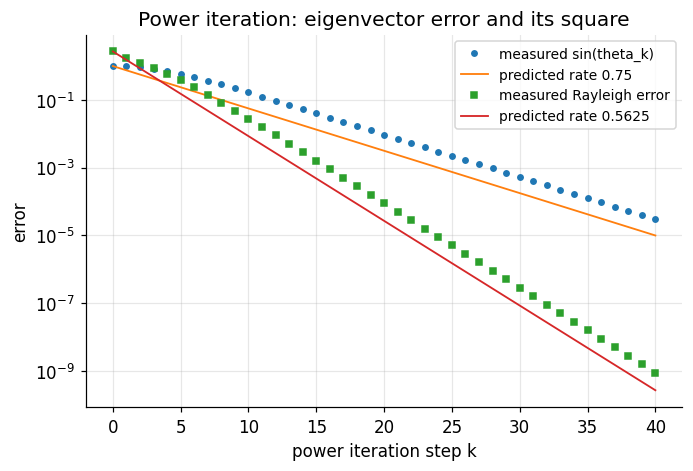

In [7]:
fig, ax = plt.subplots(figsize=(7.0, 4.4))
k_axis = np.arange(41)
ratio = spectrum[1] / spectrum[0]
ax.semilogy(k_axis, sin_err, "o", ms=3.5, label="measured sin(theta_k)")
ax.semilogy(k_axis, sin_err[0] * ratio ** k_axis, lw=1.2,
            label=f"predicted rate {ratio:.2f}")
ax.semilogy(k_axis, rq_err, "s", ms=3.5, label="measured Rayleigh error")
ax.semilogy(k_axis, rq_err[0] * ratio ** (2 * k_axis), lw=1.2,
            label=f"predicted rate {ratio**2:.4f}")
ax.set_xlabel("power iteration step k")
ax.set_ylabel("error")
ax.set_title("Power iteration: eigenvector error and its square")
ax.legend(fontsize=9)
plt.show()

Both point clouds lie on the predicted lines over ten orders of magnitude. The steeper line is
the Rayleigh-quotient error; its slope is exactly twice the other, which is the graphical form of
the statement that the Rayleigh quotient is stationary at an eigenvector.

### 7.3 Counterexamples: dropping the hypotheses

This cell runs the three matrices of Example 6.5 and prints what breaks.

- $N = \begin{pmatrix}1&1\\0&1\end{pmatrix}$ is defective: the eigenvector matrix returned by
  `numpy.linalg.eig` is singular, so $N = V\Lambda V^{-1}$ cannot be formed at all.
- $R = \begin{pmatrix}0&-1\\1&0\end{pmatrix}$ is not symmetric; calling `eigh` on it anyway
  returns confident, wrong answers, because `eigh` reads only one triangle.
- $C = \begin{pmatrix}2&1\\0&3\end{pmatrix}$ is diagonalizable but not orthogonally so.

In [8]:
N = np.array([[1.0, 1.0], [0.0, 1.0]])
wN, VN = np.linalg.eig(N)
print("defective shear N")
print("  eigenvalues           :", wN)
print("  algebraic multiplicity: 2   geometric:", 2 - np.linalg.matrix_rank(N - np.eye(2)))
print("  rank of eigenvector matrix:", np.linalg.matrix_rank(VN),
      "  cond(V) = {:.3e}".format(np.linalg.cond(VN)))
for k in (10, 100, 1000):
    print(f"  ||N^{k}||_2 = {np.linalg.norm(np.linalg.matrix_power(N, k), 2):10.4f}"
          f"   (rho(N)^{k} = 1: growth is polynomial, not geometric)")

R = np.array([[0.0, -1.0], [1.0, 0.0]])
wR, VR = np.linalg.eigh(R)
print("\nrotation R: symmetric hypothesis dropped")
print("  true spectrum      :", np.linalg.eigvals(R))
print("  what eigh returns  :", wR, " <- these are not eigenvalues of R")
for i in range(2):
    res = np.linalg.norm(R @ VR[:, i] - wR[i] * VR[:, i])
    print(f"  residual ||R q - lambda q|| for pair {i}: {res:.4f}"
          f"   ({res / EPS:.3e} * eps)")

C = np.array([[2.0, 1.0], [0.0, 3.0]])
wC, VC = np.linalg.eig(C)
print("\nnon-symmetric but diagonalizable C")
print("  eigenvector Gram matrix V^T V:\n", VC.T @ VC)
print("  ||C - V L V^T||_F   =", np.linalg.norm(C - VC @ np.diag(wC) @ VC.T))
print("  ||C - V L V^-1||_F  =", np.linalg.norm(C - VC @ np.diag(wC) @ np.linalg.inv(VC)))

defective shear N
  eigenvalues           : [1. 1.]
  algebraic multiplicity: 2   geometric: 1
  rank of eigenvector matrix: 1   cond(V) = 9.007e+15
  ||N^10||_2 =    10.0990   (rho(N)^10 = 1: growth is polynomial, not geometric)
  ||N^100||_2 =   100.0100   (rho(N)^100 = 1: growth is polynomial, not geometric)
  ||N^1000||_2 =  1000.0010   (rho(N)^1000 = 1: growth is polynomial, not geometric)

rotation R: symmetric hypothesis dropped
  true spectrum      : [0.+1.j 0.-1.j]
  what eigh returns  : [-1.  1.]  <- these are not eigenvalues of R
  residual ||R q - lambda q|| for pair 0: 1.4142   (6.369e+15 * eps)
  residual ||R q - lambda q|| for pair 1: 1.4142   (6.369e+15 * eps)

non-symmetric but diagonalizable C
  eigenvector Gram matrix V^T V:
 [[1.     0.7071]
 [0.7071 1.    ]]
  ||C - V L V^T||_F   = 2.6457513110645903
  ||C - V L V^-1||_F  = 1.1102230246251565e-16


The shear has $g_1 = 1 \lt m_1 = 2$, its eigenvector matrix has rank $1$ and condition number
$9 \times 10^{15}$, and $\lVert N^k \rVert_{\mathrm{op}}$ grows linearly in $k$ even though $\rho(N) = 1$ —
a growth mode diagonalizable matrices cannot produce.

The rotation is the loudest failure: `eigh` returns $\pm 1$ with total confidence, and the
residual $\lVert R q - \lambda q \rVert = 1.41$ is not small — it is $6 \times 10^{15}$ machine
epsilons. Reading only the lower triangle of $R$ silently replaces it by a different, symmetric
matrix. **Never call `eigh` on a matrix you have not checked is symmetric.**

The third matrix is diagonalizable, so $C = V\Lambda V^{-1}$ is exact, but its eigenvectors meet
at $45$ degrees, so $V^{\top}V \neq I$ and the orthogonal form $V\Lambda V^{\top}$ is wrong by
$2.6$ — an $O(1)$ error, not a rounding effect.

### 7.4 Hand-rolled versus library

The next cell implements two classical algorithms from scratch and checks them against
`numpy.linalg.eigh`:

- the **cyclic Jacobi rotation** method, which annihilates one off-diagonal pair at a time and
  converges to the full spectral factorization;
- **Rayleigh quotient iteration**, which solves $(A - \mu_k I) y = x_k$ with
  $\mu_k = R_A(x_k)$ and is expected to converge cubically.

In [9]:
def off_norm(X):
    """Frobenius norm of the strictly off-diagonal part."""
    return np.linalg.norm(X - np.diag(np.diag(X)))


def jacobi_eigh(A, tol=1e-15, max_sweeps=100):
    """Cyclic Jacobi eigenvalue algorithm for a real symmetric matrix."""
    n = A.shape[0]
    Awork, V, sweeps = A.copy(), np.eye(n), 0
    scale = np.linalg.norm(A)
    while off_norm(Awork) > tol * scale and sweeps < max_sweeps:
        for p in range(n - 1):
            for q in range(p + 1, n):
                if Awork[p, q] == 0.0:
                    continue
                theta = (Awork[q, q] - Awork[p, p]) / (2.0 * Awork[p, q])
                t = (np.sign(theta) / (abs(theta) + np.sqrt(theta * theta + 1.0))
                     if theta != 0.0 else 1.0)
                c = 1.0 / np.sqrt(t * t + 1.0)
                s = t * c
                J = np.eye(n)
                J[p, p] = J[q, q] = c
                J[p, q], J[q, p] = s, -s
                Awork = J.T @ Awork @ J
                V = V @ J
        sweeps += 1
    return np.diag(Awork).copy(), V, sweeps


Mj = rng.standard_normal((6, 6))
Sj = (Mj + Mj.T) / 2
lam_j, V_j, sweeps = jacobi_eigh(Sj)
idx = np.argsort(lam_j)[::-1]
lam_j, V_j = lam_j[idx], V_j[:, idx]
lam_ref = np.linalg.eigvalsh(Sj)[::-1]

print(f"Jacobi: {sweeps} sweeps")
print("  hand-rolled :", lam_j)
print("  numpy eigh  :", lam_ref)
print(f"  max |difference|      = {np.abs(lam_j - lam_ref).max():.3e}"
      f"  = {np.abs(lam_j - lam_ref).max() / EPS:.1f} * eps")
print(f"  ||S - V L V^T||_F     = {np.linalg.norm(Sj - V_j @ np.diag(lam_j) @ V_j.T):.3e}")
print(f"  ||V^T V - I||_F       = {np.linalg.norm(V_j.T @ V_j - np.eye(6)):.3e}")

x = rng.standard_normal(6)
x /= np.linalg.norm(x)
print("\nRayleigh quotient iteration")
mus = []
for k in range(5):
    mu = x @ Sj @ x
    mus.append(mu)
    y = np.linalg.solve(Sj - mu * np.eye(6), x)
    x = y / np.linalg.norm(y)
mu_final = x @ Sj @ x
target = lam_ref[np.argmin(np.abs(lam_ref - mu_final))]
for k, mu in enumerate(mus):
    print(f"  k={k}  mu = {mu:.14f}   |mu - lambda| = {abs(mu - target):.3e}")
print(f"  converged to eigenvalue {target:.14f}")
print(f"  final residual ||S x - mu x|| = {np.linalg.norm(Sj @ x - mu_final * x):.3e}")

Jacobi: 6 sweeps
  hand-rolled : [ 2.8517  1.781   0.6789 -0.3946 -1.8634 -2.1087]
  numpy eigh  : [ 2.8517  1.781   0.6789 -0.3946 -1.8634 -2.1087]
  max |difference|      = 1.332e-15  = 6.0 * eps
  ||S - V L V^T||_F     = 3.681e-15
  ||V^T V - I||_F       = 1.425e-15

Rayleigh quotient iteration
  k=0  mu = 0.20152404672065   |mu - lambda| = 4.774e-01
  k=1  mu = 0.50805282049587   |mu - lambda| = 1.708e-01
  k=2  mu = 0.67255907449082   |mu - lambda| = 6.331e-03
  k=3  mu = 0.67889021078831   |mu - lambda| = 2.193e-07
  k=4  mu = 0.67889043010490   |mu - lambda| = 5.551e-16
  converged to eigenvalue 0.67889043010489
  final residual ||S x - mu x|| = 1.556e-16


The hand-rolled Jacobi spectrum matches `eigh` to six machine epsilons, and the reconstruction
and orthogonality residuals sit at the same level — two independent algorithms landing on the
same answer is stronger evidence than either one alone.

Rayleigh quotient iteration shows the signature cubic pattern: the errors run
$4.8 \times 10^{-1}$, $1.7 \times 10^{-1}$, $6.3 \times 10^{-3}$, $2.2 \times 10^{-7}$, and then
machine precision — each exponent roughly tripling. That is the practical payoff of the squared
Rayleigh accuracy in Theorem 4.7, compounded by the shift.

### 7.5 Gershgorin discs against the true spectrum

The next figure draws the four discs of Example 6.4 in the complex plane and overlays the
eigenvalues of $G$.

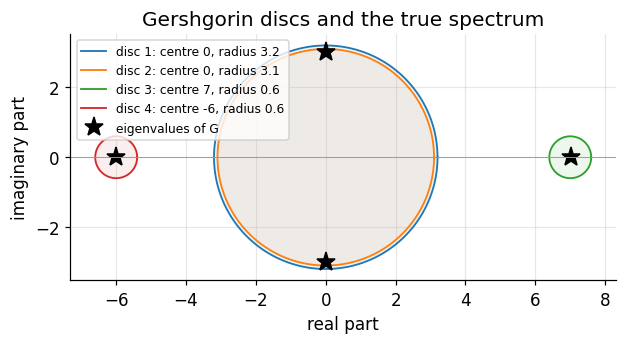

eigenvalue -> containing discs
  +0.000135+2.998976j  ->  [1, 2]
  +0.000135-2.998976j  ->  [1, 2]
  +7.017839+0.000000j  ->  [3]
  -6.018110+0.000000j  ->  [4]


In [10]:
centres = np.diag(G)
radii = np.abs(G).sum(axis=1) - np.abs(centres)
evG = np.linalg.eigvals(G)

fig, ax = plt.subplots(figsize=(6.4, 6.0))
angles = np.linspace(0.0, 2.0 * np.pi, 300)
for i in range(4):
    ax.plot(centres[i] + radii[i] * np.cos(angles), radii[i] * np.sin(angles),
            lw=1.2, label=f"disc {i + 1}: centre {centres[i]:.0f}, radius {radii[i]:.1f}")
    ax.fill(centres[i] + radii[i] * np.cos(angles), radii[i] * np.sin(angles), alpha=0.08)
ax.plot(evG.real, evG.imag, "k*", ms=13, label="eigenvalues of G")
ax.axhline(0.0, lw=0.6, color="0.6")
ax.set_aspect("equal")
ax.set_xlabel("real part")
ax.set_ylabel("imaginary part")
ax.set_title("Gershgorin discs and the true spectrum")
ax.legend(fontsize=8, loc="upper left")
plt.show()

print("eigenvalue -> containing discs")
for z in evG:
    hits = [i + 1 for i in range(4) if abs(z - centres[i]) <= radii[i] + 1e-12]
    print(f"  {z.real:+.6f}{z.imag:+.6f}j  ->  {hits}")

Every star lies inside at least one circle, as Theorem 4.8 requires. The two isolated discs each
contain exactly one eigenvalue, and the two overlapping discs around the origin contain exactly
two — the refinement's count, confirmed.

The complex pair also shows why a real matrix needs discs in the plane: a real-interval version
of the theorem would be false here.

### 7.6 The Davis-Kahan bound that is usually misquoted

The last experiment settles the form of Theorem 4.9. Take $A = \operatorname{diag}(1, 0)$, whose
top eigenvector is $q_1 = (1,0)$ and whose gap is $\delta = 1$, and perturb by

$$
E = \begin{pmatrix} -0.45 & 0.2 \\ 0.2 & 0.45 \end{pmatrix} .
$$

The cell prints $\sin\theta(q_1, \tilde{q}_1)$ against the frequently quoted bound
$\lVert E \rVert_{\mathrm{op}} / \delta$ and against the correct bound $2\lVert E \rVert_{\mathrm{op}} / \delta$.

In [11]:
Adk = np.diag([1.0, 0.0])
Edk = np.array([[-0.45, 0.20], [0.20, 0.45]])
gap = 1.0
normE = np.linalg.norm(Edk, 2)

_, Va = np.linalg.eigh(Adk)
wb, Vb = np.linalg.eigh(Adk + Edk)
q_a, q_b = Va[:, -1], Vb[:, -1]
sin_theta = np.sqrt(max(0.0, 1.0 - (q_a @ q_b) ** 2))

print("eigenvalues of A     :", np.diag(Adk))
print("eigenvalues of A + E :", wb[::-1])
print(f"||E||_op             = {normE:.6f}")
print(f"gap delta            = {gap:.6f}")
print(f"sin theta (measured) = {sin_theta:.6f}")
print(f"quoted bound  ||E||/delta   = {normE / gap:.6f}"
      f"   satisfied: {sin_theta <= normE / gap}")
print(f"correct bound 2||E||/delta  = {2 * normE / gap:.6f}"
      f"   satisfied: {sin_theta <= 2 * normE / gap}")
assert sin_theta > normE / gap
assert sin_theta <= 2 * normE / gap

eigenvalues of A     : [1. 0.]
eigenvalues of A + E : [0.7062 0.2938]
||E||_op             = 0.492443
gap delta            = 1.000000
sin theta (measured) = 0.615412
quoted bound  ||E||/delta   = 0.492443   satisfied: False
correct bound 2||E||/delta  = 0.984886   satisfied: True


The measured rotation is $\sin\theta = 0.6154$ while $\lVert E \rVert_{\mathrm{op}}/\delta = 0.4924$: the bound
without the factor $2$ is violated by $25$ percent, in a regime where the perturbation is well
under half the gap. The Yu-Wang-Samworth form with the factor $2$ holds.

This is why Theorem 4.9 is stated with the factor and with the gap read off the *unperturbed*
spectrum. A perturbation bound quoted without its constant is not a weaker theorem; it is a false
one.

## 8. Applications

Four settings use Theorem 4.2 as their engine. In each, the object being diagonalized is
symmetric for a structural reason, not by accident.

### 8.1 Principal component analysis

For column-centred data $X \in \mathbb{R}^{m \times n}$ the sample covariance
$\Sigma = \tfrac{1}{m-1} X^{\top} X$ is symmetric positive semidefinite, so Theorem 4.2 gives
$\Sigma = Q \Lambda Q^{\top}$ with $\lambda_1 \ge \dots \ge \lambda_n \ge 0$.

By Theorem 4.4 the direction of maximal variance is $q_1$, with variance $\lambda_1$, and the
best $k$-dimensional subspace is $\operatorname{span}(q_1, \dots, q_k)$.

The fraction of total variance retained is

$$
\frac{\lambda_1 + \dots + \lambda_k}{\lambda_1 + \dots + \lambda_n},
$$

because $\operatorname{tr}\Sigma = \sum_i \lambda_i$ is the total variance.

### 8.2 Markov chains

Let $P$ be **column-stochastic**, so $P_{ij} = \mathbb{P}(X_{t+1} = i \mid X_t = j)$ and every
column sums to $1$. A distribution is a column vector $\pi$ with non-negative entries summing to
one, and one step of the chain is $\pi \mapsto P\pi$.

A stationary distribution is an eigenvector for eigenvalue $1$:

$$
P \pi = \pi .
$$

Since $\mathbf{1}^{\top} P = \mathbf{1}^{\top}$, the value $1$ is always an eigenvalue, and by
Theorem 4.8 applied to $P^{\top}$ every eigenvalue satisfies $\lvert \lambda \rvert \le 1$. The
convergence rate of $P^k \pi_0$ to $\pi$ is governed by $\lvert \lambda_2 \rvert$, the second
largest eigenvalue in modulus.

$P$ is generally **not** symmetric, so this is a Theorem 4.1 situation, not a Theorem 4.2 one —
which is exactly why Markov chains need Perron-Frobenius theory rather than the spectral theorem.

### 8.3 Spectral graph theory

For an undirected graph with adjacency matrix $W$ and degree matrix $D$, the Laplacian
$L = D - W$ is symmetric, and for every $x$,

$$
x^{\top} L x = \sum_{(i,j) \in E} (x_i - x_j)^2 \ \ge \ 0,
$$

so $L$ is positive semidefinite with $L\mathbf{1} = 0$.

> **Ordering callout.** For Laplacian spectra only, this repository reverses its default and
> lists eigenvalues **ascending**, $0 = \lambda_1 \le \lambda_2 \le \cdots \le \lambda_n$, so
> that $\lambda_2$ is the algebraic connectivity and the multiplicity of $0$ counts connected
> components. Everywhere else in this module the order is descending.

By Theorem 4.4, in that ascending indexing,

$$
\lambda_2(L) = \min_{x \perp \mathbf{1}, \, x \neq 0} \frac{\sum_{(i,j) \in E}(x_i - x_j)^2}{\lVert x \rVert^2},
$$

the **algebraic connectivity**. It is positive exactly when the graph is connected, and its
eigenvector — the Fiedler vector — sorts the vertices into two loosely connected groups. This is
the whole of spectral clustering.

### 8.4 Physics: normal modes and observables

For a mechanical system with symmetric stiffness $K$ and mass $M \succ 0$, small oscillations
solve $M\ddot{x} = -Kx$. Substituting $x = v e^{i\omega t}$ gives the generalized eigenproblem

$$
K v = \omega^2 M v,
$$

which reduces to a symmetric problem for $M^{-1/2} K M^{-1/2}$. The eigenvalues are the squared
natural frequencies and the eigenvectors are the normal modes, which oscillate independently
precisely because Theorem 4.2 makes them orthogonal.

In quantum mechanics an observable is a self-adjoint operator $H = H^{\ast}$. Theorem 4.3
forces its spectrum to be real — measured values are real numbers — and its eigenstates to be
orthogonal, which is what makes $\lvert \langle \psi_k \mid \Psi \rangle \rvert^2$ a probability
distribution over outcomes.

The cell below runs all three of the computational applications on small explicit objects: a PCA
on synthetic data with a known covariance, a two-state column-stochastic chain, and the Laplacian
of a four-vertex path.

In [12]:
# --- 8.1 PCA -------------------------------------------------------------
Sigma_true = np.array([[3.0, 1.0], [1.0, 3.0]])
L_chol = np.linalg.cholesky(Sigma_true)
Xdata = (L_chol @ rng.standard_normal((2, 4000))).T
Xdata -= Xdata.mean(axis=0)
Sigma_hat = Xdata.T @ Xdata / (Xdata.shape[0] - 1)
lam_pca, Q_pca = np.linalg.eigh(Sigma_hat)
lam_pca, Q_pca = lam_pca[::-1], Q_pca[:, ::-1]
print("PCA")
print("  population eigenvalues :", np.linalg.eigvalsh(Sigma_true)[::-1], " -> variance explained 4/6 = 0.6667")
print("  sample eigenvalues     :", lam_pca)
print("  first PC direction     :", Q_pca[:, 0], " (population: +/- (1,1)/sqrt2 = +/- 0.7071)")
print("  variance explained     :", lam_pca[0] / lam_pca.sum())

# --- 8.2 Markov chain ----------------------------------------------------
P = np.array([[0.8, 0.3], [0.2, 0.7]])
print("\nMarkov chain (column-stochastic)")
print("  column sums            :", P.sum(axis=0))
evP, VP = np.linalg.eig(P)
i1 = int(np.argmin(np.abs(evP - 1.0)))
pi = np.real(VP[:, i1])
pi = pi / pi.sum()
lam2 = evP[np.argsort(-np.abs(evP))[1]]
print("  eigenvalues            :", np.real_if_close(evP))
print("  stationary pi          :", pi, "   ||P pi - pi|| =", np.linalg.norm(P @ pi - pi))
p0 = np.array([1.0, 0.0])
prev = None
for k in (1, 2, 5, 10, 20):
    pk = np.linalg.matrix_power(P, k) @ p0
    err = np.linalg.norm(pk - pi)
    tail = "" if prev is None else f"   per-step error ratio = {(err / prev[1])**(1 / (k - prev[0])):.6f}"
    print(f"  k={k:2d}  P^k e1 = {pk}   ||P^k e1 - pi|| = {err:.3e}{tail}")
    prev = (k, err)
print(f"  |lambda2| = {abs(lam2):.6f}  <- the predicted per-step contraction factor")

# --- 8.3 Graph Laplacian -------------------------------------------------
W = np.array([[0.0, 1, 0, 0], [1, 0, 1, 0], [0, 1, 0, 1], [0, 0, 1, 0]])
Lap = np.diag(W.sum(axis=1)) - W
lam_L, Q_L = np.linalg.eigh(Lap)
print("\nPath graph on 4 vertices")
print("  Laplacian spectrum     :", lam_L)
print("  closed form 2-2cos(k pi/4):", np.array([2 - 2 * np.cos(k * np.pi / 4) for k in range(4)]))
print("  algebraic connectivity :", lam_L[1])
print("  Fiedler vector         :", Q_L[:, 1])
print("  induced bipartition    :", np.sign(Q_L[:, 1]).astype(int))
assert lam_L[1] > 0
assert np.allclose(lam_L, [2 - 2 * np.cos(k * np.pi / 4) for k in range(4)])

PCA
  population eigenvalues : [4. 2.]  -> variance explained 4/6 = 0.6667
  sample eigenvalues     : [4.0282 2.0033]
  first PC direction     : [0.6977 0.7164]  (population: +/- (1,1)/sqrt2 = +/- 0.7071)
  variance explained     : 0.6678581071952282

Markov chain (column-stochastic)
  column sums            : [1. 1.]
  eigenvalues            : [1.  0.5]
  stationary pi          : [0.6 0.4]    ||P pi - pi|| = 0.0
  k= 1  P^k e1 = [0.8 0.2]   ||P^k e1 - pi|| = 2.828e-01
  k= 2  P^k e1 = [0.7 0.3]   ||P^k e1 - pi|| = 1.414e-01   per-step error ratio = 0.500000
  k= 5  P^k e1 = [0.6125 0.3875]   ||P^k e1 - pi|| = 1.768e-02   per-step error ratio = 0.500000
  k=10  P^k e1 = [0.6004 0.3996]   ||P^k e1 - pi|| = 5.524e-04   per-step error ratio = 0.500000
  k=20  P^k e1 = [0.6 0.4]   ||P^k e1 - pi|| = 5.395e-07   per-step error ratio = 0.500000
  |lambda2| = 0.500000  <- the predicted per-step contraction factor

Path graph on 4 vertices
  Laplacian spectrum     : [-0.      0.5858  2.      3.

The sample covariance recovers the population eigenvalues $4$ and $2$ to within one percent at
$4000$ samples, the estimated principal direction is within a degree of $(1,1)/\sqrt2$, and the
variance explained is $0.668$ against the exact $2/3$.

The Markov chain converges to $\pi = (0.6, 0.4)$ with an observed per-step contraction factor of
exactly $0.5 = \lvert \lambda_2 \rvert$ — here the second eigenvalue is not a bound, it is the
measured rate.

The path Laplacian reproduces the closed form $2 - 2\cos(k\pi/4)$ exactly, its algebraic
connectivity is positive because the path is connected, and the sign pattern of the Fiedler
vector cuts the path in the middle, which is the minimum-cut answer.

## 9. Key Takeaways

- **Every complex square matrix is unitarily triangularizable**: $A = UTU^{\ast}$ with $T$ upper
  triangular (Theorem 4.1). The only hypothesis is that the field is $\mathbb{C}$.

- **Every real symmetric matrix is orthogonally diagonalizable**: $A = Q\Lambda Q^{\top}$ with
  $Q^{\top}Q = I$ and $\Lambda$ real (Theorem 4.2). It follows from Theorem 4.1 because
  $T = T^{\ast}$ forces $T$ diagonal; the equality $g_\lambda = m_\lambda$ is a consequence of
  this, never an input to it.

- **Unitary diagonalizability is exactly normality**: $A = UDU^{\ast}$ if and only if
  $A^{\ast}A = AA^{\ast}$ (Theorem 4.3).

- **Eigenvalues of a symmetric matrix are variational**: $\lambda_k$ is a max-min of the Rayleigh
  quotient over $k$-dimensional subspaces (Theorem 4.4). Interlacing (Theorem 4.5) and Weyl's
  inequality (Theorem 4.6) both drop straight out of it.

- **Symmetric eigenvalues are perfectly conditioned**:
  $\lvert \lambda_k(A+E) - \lambda_k(A) \rvert \le \lVert E \rVert_{\mathrm{op}}$ with no amplification factor,
  and the bound is attained (Example 6.3). Eigen*vectors* are not: their sensitivity is
  $2\lVert E \rVert_{\mathrm{op}}$ divided by the spectral gap (Theorem 4.9).

- **Localization is free**: every eigenvalue lies in a Gershgorin disc built from one row of $A$,
  and isolated groups of discs hold exactly as many eigenvalues as they have discs (Theorem 4.8).

- **Power iteration converges at rate $\lambda_2/\lambda_1$ and the Rayleigh quotient at its
  square** (Theorem 4.7). Section 7 measures $0.750010$ and $0.562515$ against predictions of
  $0.75$ and $0.5625$.

- **Without symmetry, three separate things fail**: the spectrum can leave $\mathbb{R}$, the
  eigenspaces can be too small to span, and even when they span they need not be orthogonal
  (Example 6.5). Calling `eigh` on a non-symmetric matrix returns a wrong answer without warning.

## 10. References

**Textbooks.**

- Axler, S. *Linear Algebra Done Right*, 3rd ed., section 7.B — the complex and real spectral
  theorems, developed operator-theoretically without determinants.
- Horn, R. A. and Johnson, C. R. *Matrix Analysis*, 2nd ed. — Schur triangularization
  (Theorem 2.3.1), the Hermitian spectral theorem (Theorem 2.5.6), Courant-Fischer
  (Theorem 4.2.6), Weyl's inequality (Theorem 4.3.1), Cauchy interlacing (Theorem 4.3.17),
  Gershgorin and its connected-component refinement (Theorem 6.1.1).
- Trefethen, L. N. and Bau, D. *Numerical Linear Algebra*, Lecture 24 (eigenvalue problems and
  the Schur factorization), Lecture 27 (Rayleigh quotient, inverse iteration and the quadratic
  and cubic convergence rates).
- Golub, G. H. and Van Loan, C. F. *Matrix Computations*, 4th ed., section 8.1 (properties and
  decompositions of the symmetric eigenproblem), section 8.2 (power and inverse iteration),
  section 8.5 (Jacobi methods).
- Strang, G. *Linear Algebra and Learning from Data*, sections I.6 and I.7 (eigenvalues and
  symmetric positive definite matrices), section I.9 (principal components).

**Papers.**

- Bauer, F. L. and Fike, C. T. "Norms and exclusion theorems", *Numerische Mathematik* **2**
  (1960), 137-141.
- Davis, C. and Kahan, W. M. "The rotation of eigenvectors by a perturbation. III",
  *SIAM Journal on Numerical Analysis* **7**(1) (1970), 1-46.
- Yu, Y., Wang, T. and Samworth, R. J. "A useful variant of the Davis-Kahan theorem for
  statisticians", *Biometrika* **102**(2) (2015), 315-323 — Theorem 2 is the form quoted in
  Theorem 4.9.

**Within this repository.**

- Prerequisites and downstream modules: [the module graph](../../docs/prerequisites.md).
- Symbol conventions: [the notation register](../../docs/notation.md).
- Orthonormalization and QR, used in the basis extension of Proof 5.1:
  [Module 04](../04_orthogonality_projections_and_qr/).
- Determinants and the characteristic polynomial, used in Definition 3.2 and Proof 5.9:
  [Module 05](../05_determinants_trace_and_matrix_polynomials/).
- Practice problems for this module: [exercises.ipynb](exercises.ipynb).